In [70]:
from cProfile import label

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [71]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.head(10)

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


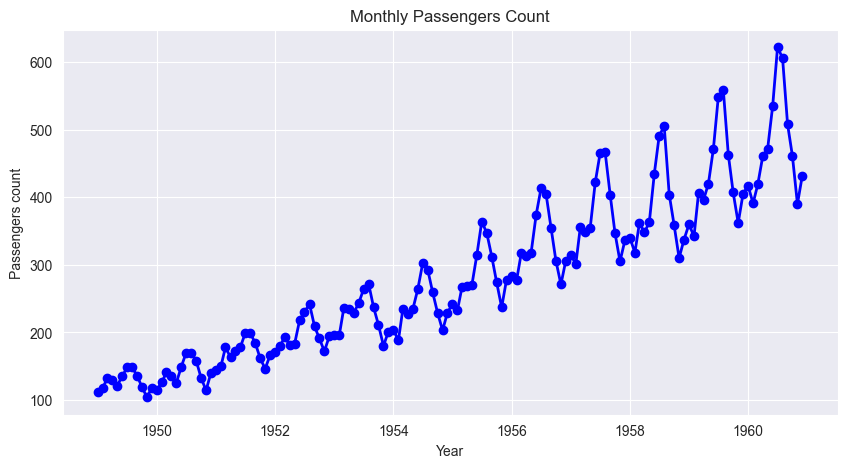

In [72]:
plt.figure(figsize=(10,5))
plt.plot(df, color='blue', marker='o', linestyle='-', linewidth=2, markersize=6)
plt.title('Monthly Passengers Count')
plt.xlabel('Year')
plt.ylabel('Passengers count')
plt.show()

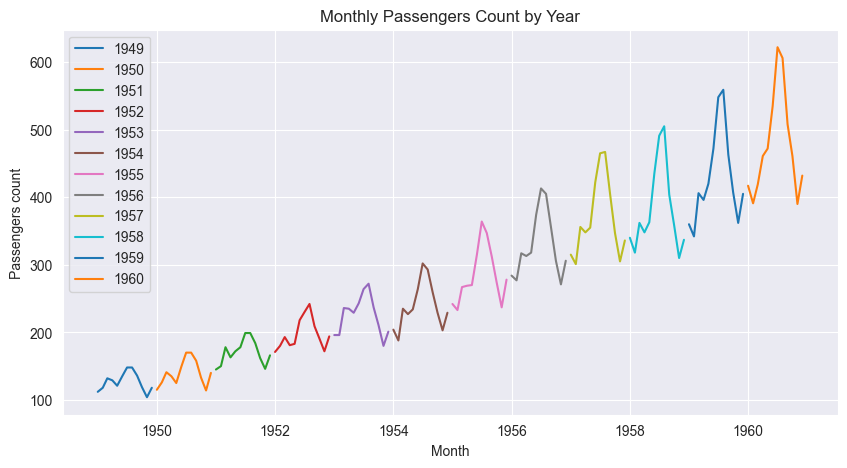

In [73]:
#Extract years from data
years = df.index.year.unique()

#Plotting each year its own line
plt.figure(figsize=(10,5))
for year in years:
    year_data = df[df.index.year == year]
    plt.plot(year_data['Passengers'], label=year)

plt.title('Monthly Passengers Count by Year')
plt.xlabel('Month')
plt.ylabel('Passengers count')
plt.legend()
plt.show()

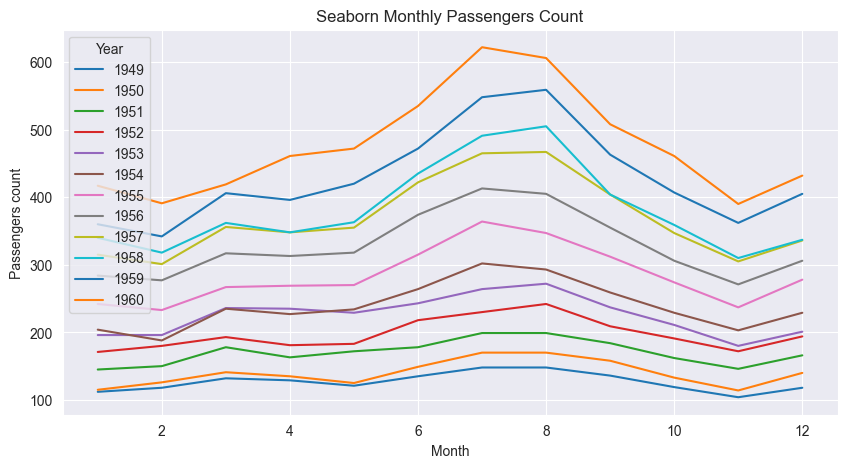

In [74]:
#Plot seasonal subseries
df['Year'] = df.index.year
df['month'] = df.index.month

#Pivot table - Sacamos cada año y los meses
table = pd.pivot_table(df,
                       values='Passengers',
                       index=['month'],
                       columns='Year',
                       aggfunc='sum')

#plot the series
fig, ax = plt.subplots(figsize=(10,5))
table.plot(ax=ax, kind='line', legend=True)
ax.set_xlabel('Month')
ax.set_ylabel('Passengers count')
ax.set_title('Seaborn Monthly Passengers Count')
plt.grid(True)
plt.show()

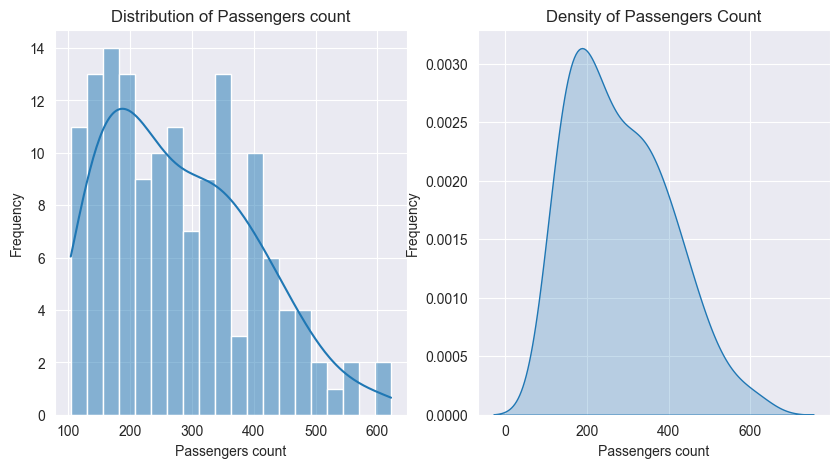

In [75]:
import seaborn as sns

#Histogram
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(df['Passengers'], bins=20, kde=True)
plt.title('Distribution of Passengers count')
plt.xlabel('Passengers count')
plt.ylabel('Frequency')

#Density
plt.subplot(1,2,2)
sns.kdeplot(df['Passengers'], fill=True)
plt.title('Density of Passengers Count')
plt.xlabel('Passengers count')
plt.ylabel('Frequency')
plt.show()

In [76]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose

In [77]:
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 4)


In [78]:
def plot_series(s, title):
    s.plot()
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.grid(True)
    plt.show()

def adf_test(x):
    res = adfuller(x, autolag='AIC')
    key = ['test_stat', 'pvalue', 'lags', 'nobs', 'critical_values', 'icbest']
    return dict(zip(key, [res[0], res[1], res[2], res[3], res[4], res[5]]))

def kpss_test(x, regression='c', nlag='auto'):
    stat, pvalue, lags, crit = kpss(x, regression=regression, nlags=nlag)
    return {'test_stat': stat, 'pvalue': pvalue, 'lags': lags, 'critical_values': crit, 'regression': regression}

def print_test(x, name='series'):
    print(f'Test {name}')
    a = adf_test(x)
    print(f'ADF Statistic: {a['test_stat']:.3f} p={a['pvalue']}')
    try:
        k = kpss_test(x)
        print(f'KPSS: stat={k['test_stat']:.3f} p={k['pvalue']}')
    except:
        print('KPSS test failes')

def rolling_mean_var(s, window=24, title='Rolling Mean & Var'):
    rolling_mean = s.rolling(window).mean()
    rolling_var = s.rolling(window).var()
    fig, ax = plt.subplots(2, 1, figsize=(10, 6))
    ax[0].plot(s, label='Original')
    ax[0].plot(rolling_mean, label='Rolling Mean')
    ax[0].legend()
    ax[0].set_title(title + '- mean')
    ax[1].plot(rolling_var, label='Rolling Var')
    ax[1].legend()
    ax[1].set_title(title + '- var')
    plt.show()


In [79]:
n = 240 #meses
t = np.arange(n)

#stationary: white noise
white_noise = pd.Series(np.random.normal(0,1,n))

#no estacionaria
trend = .02 * t
trended = pd.Series(trend +np.random.normal(0, 1, n))



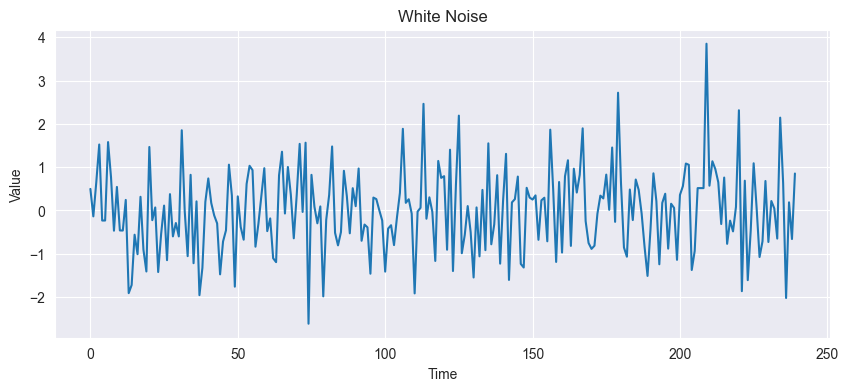

Test White Noise
ADF Statistic: -16.112 p=5.006520467194107e-29
KPSS: stat=0.298 p=0.1


/var/folders/s9/nmcxfjds7tl85gtpmnq8yhv40000gn/T/ipykernel_30772/3221362350.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pvalue, lags, crit = kpss(x, regression=regression, nlags=nlag)


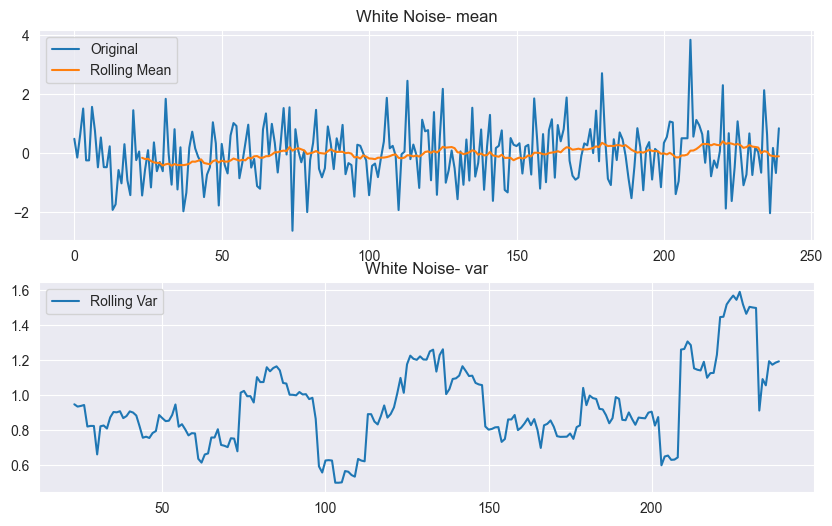

In [80]:
plot_series(white_noise, 'White Noise')
print_test(white_noise, 'White Noise')
rolling_mean_var(white_noise, title='White Noise')

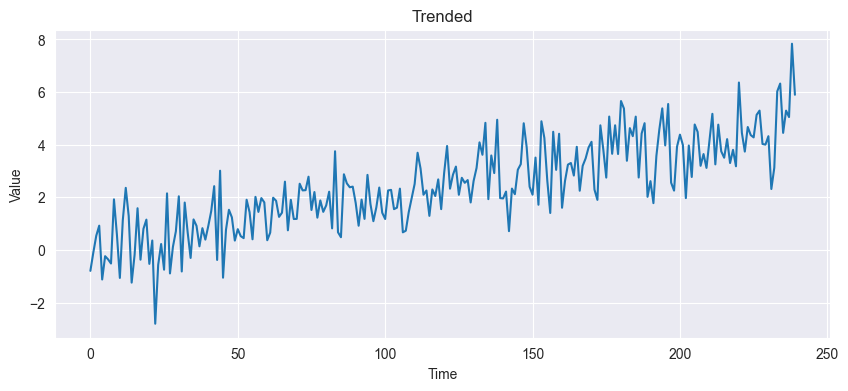

Test Trended
ADF Statistic: -0.057 p=0.9535945013089627
KPSS: stat=2.416 p=0.01


/var/folders/s9/nmcxfjds7tl85gtpmnq8yhv40000gn/T/ipykernel_30772/3221362350.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pvalue, lags, crit = kpss(x, regression=regression, nlags=nlag)


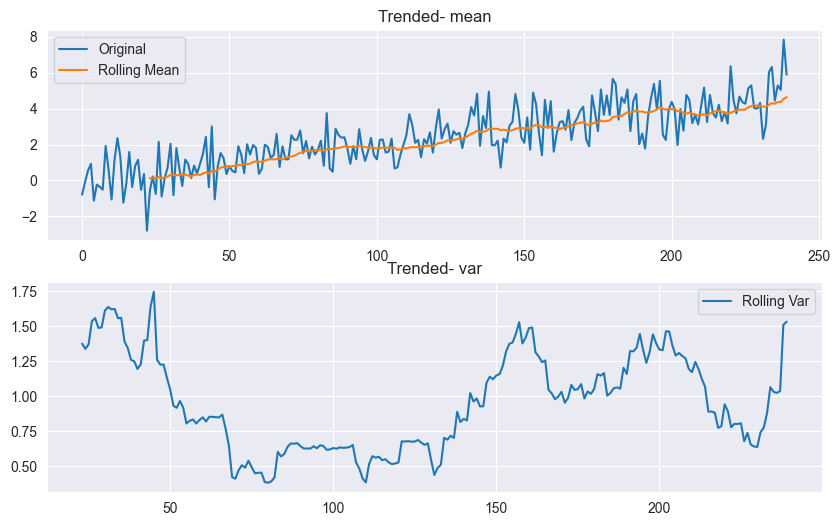

In [81]:
plot_series(trended, 'Trended')
print_test(trended, 'Trended')
rolling_mean_var(trended, window=24, title='Trended')

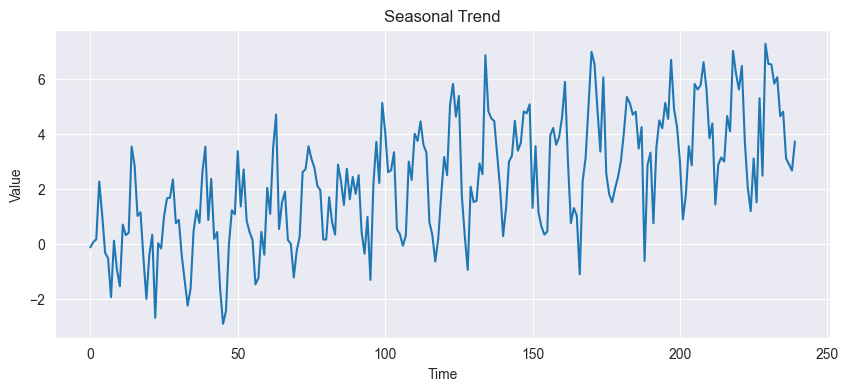

Test Seasonal Trend
ADF Statistic: -0.530 p=0.8860859361543612
KPSS: stat=2.407 p=0.01


/var/folders/s9/nmcxfjds7tl85gtpmnq8yhv40000gn/T/ipykernel_30772/3221362350.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pvalue, lags, crit = kpss(x, regression=regression, nlags=nlag)


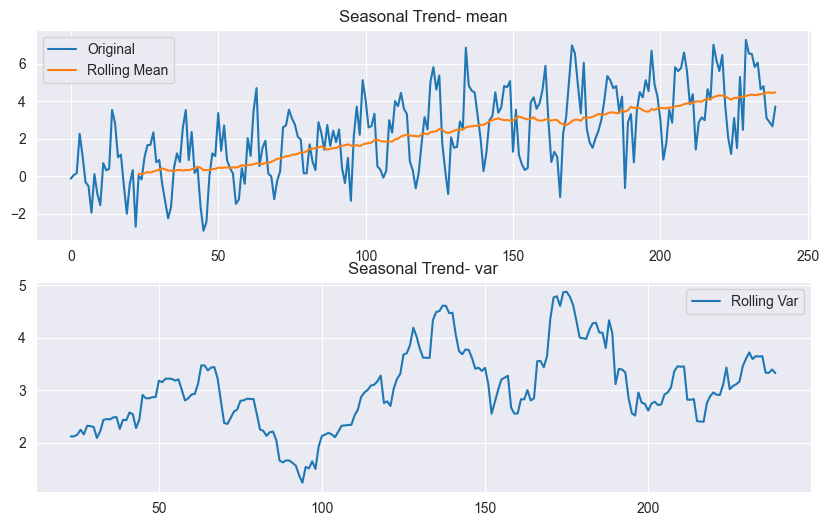

In [82]:
#seasonal  + trend
seasonal = 2 * np.sin(2*np.pi*t/12)
trend = 0.02 * t
season_trend = pd.Series(trend + seasonal + np.random.normal(0,1,n))
plot_series(season_trend, 'Seasonal Trend')
print_test(season_trend, 'Seasonal Trend')
rolling_mean_var(season_trend, window=24, title='Seasonal Trend')

In [83]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.head(10)

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


In [84]:
df.rename(columns={'Passengers':'y'}, inplace=True)
df.head()

,y
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


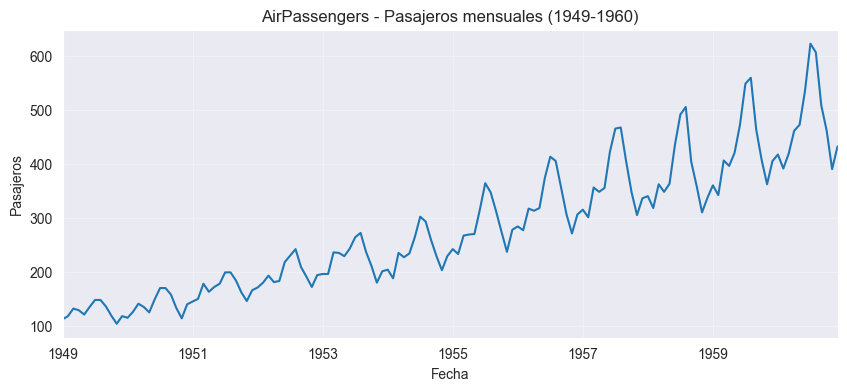

In [85]:
ax = df['y'].plot()
ax.set_title('AirPassengers - Pasajeros mensuales (1949-1960)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Pasajeros')
ax.grid(True, alpha=0.3)
plt.show()

In [86]:
from statsmodels.tsa.seasonal import seasonal_decompose

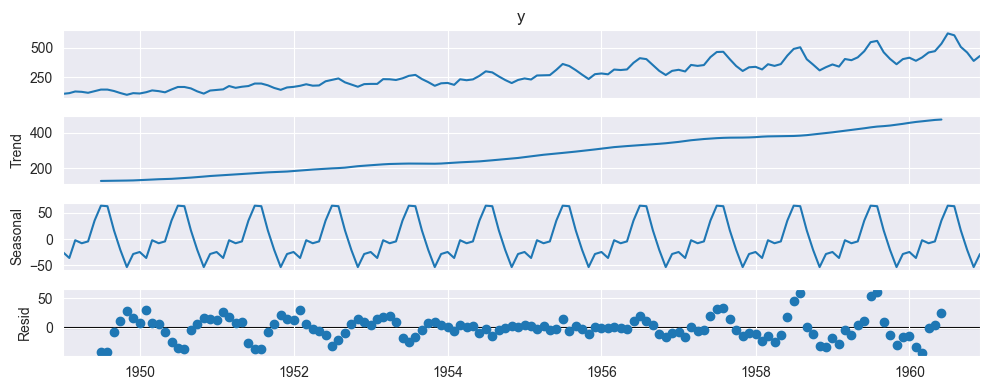

In [87]:
decomp = seasonal_decompose(df['y'], model='additive', period=12)
decomp.plot()
plt.show()

In [88]:
from statsmodels.tsa.ar_model import AutoReg

model = AutoReg(df['y'], lags =1)
model_fit = model.fit()

print(model_fit.summary())

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  144
Model:                     AutoReg(1)   Log Likelihood                -704.106
Method:               Conditional MLE   S.D. of innovations             33.277
Date:                Fri, 14 Nov 2025   AIC                           1414.212
Time:                        15:36:27   BIC                           1423.100
Sample:                    02-01-1949   HQIC                          1417.823
                         - 12-01-1960                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.7055      7.084      1.935      0.053      -0.178      27.589
y.L1           0.9589      0.023     41.106      0.000       0.913       1.005
                                    Roots           

/Users/wil/Documents/TEC/AdvancedAI_Python-Stats/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


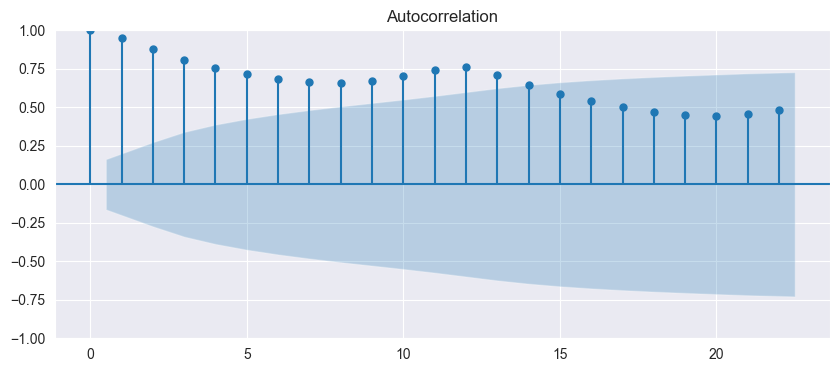

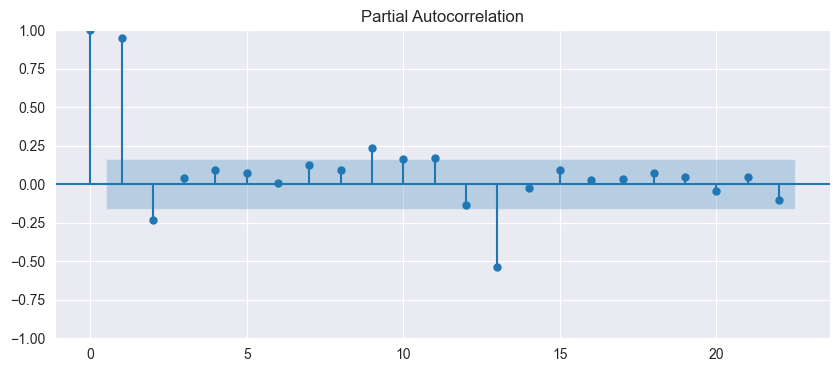

In [89]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['y'])
plt.show()
plot_pacf(df['y'])
plt.show()

In [90]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['y'], order = (12,1,1))
model_fit = model.fit()

print(model_fit.summary())

/Users/wil/Documents/TEC/AdvancedAI_Python-Stats/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/wil/Documents/TEC/AdvancedAI_Python-Stats/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/wil/Documents/TEC/AdvancedAI_Python-Stats/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/wil/Documents/TEC/AdvancedAI_Python-Stats/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary sta

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  144
Model:                ARIMA(12, 1, 1)   Log Likelihood                -558.719
Date:                Fri, 14 Nov 2025   AIC                           1145.438
Time:                        15:36:28   BIC                           1186.918
Sample:                    01-01-1949   HQIC                          1162.293
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1043      0.066      1.572      0.116      -0.026       0.234
ar.L2         -0.0917      0.060     -1.529      0.126      -0.209       0.026
ar.L3          0.0105      0.054      0.194      0.8

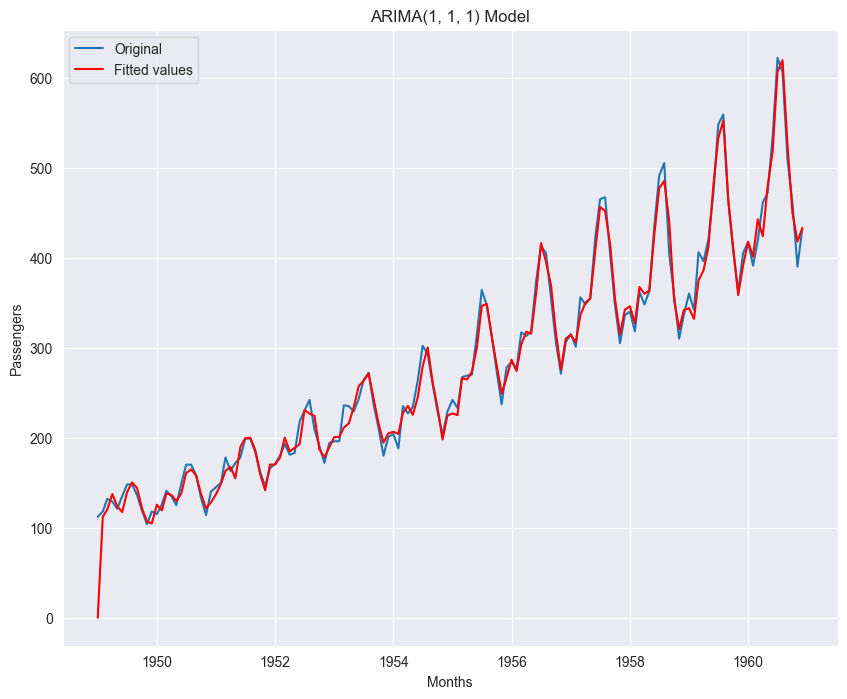

In [91]:
plt.figure(figsize=(10, 8))
plt.plot(df['y'], label = 'Original')
plt.plot(model_fit.fittedvalues, color = 'red', label = 'Fitted values')
plt.title('ARIMA(1, 1, 1) Model')
plt.xlabel('Months')
plt.ylabel('Passengers')
plt.legend()
plt.show()

**Exercise 1**

Use the sunspots dataset from kaggel to demonstrate basic conceptos of time series

In [92]:
from datetime import date

In [93]:
df = pd.read_csv('Sunspots.csv')
df.head(10)

,Unnamed: 0,Date,Monthly Mean Total Sunspot Number
0,0,1749-01-31,96.7
1,1,1749-02-28,104.3
2,2,1749-03-31,116.7
3,3,1749-04-30,92.8
4,4,1749-05-31,141.7
5,5,1749-06-30,139.2
6,6,1749-07-31,158.0
7,7,1749-08-31,110.5
8,8,1749-09-30,126.5
9,9,1749-10-31,125.8


In [94]:
df['Date'] = pd.to_datetime(df['Date'])
sunspots = df.set_index('Date')

sunspots.head()

,Unnamed: 0,Monthly Mean Total Sunspot Number
Date,,
1749-01-31,0,96.7
1749-02-28,1,104.3
1749-03-31,2,116.7
1749-04-30,3,92.8
1749-05-31,4,141.7


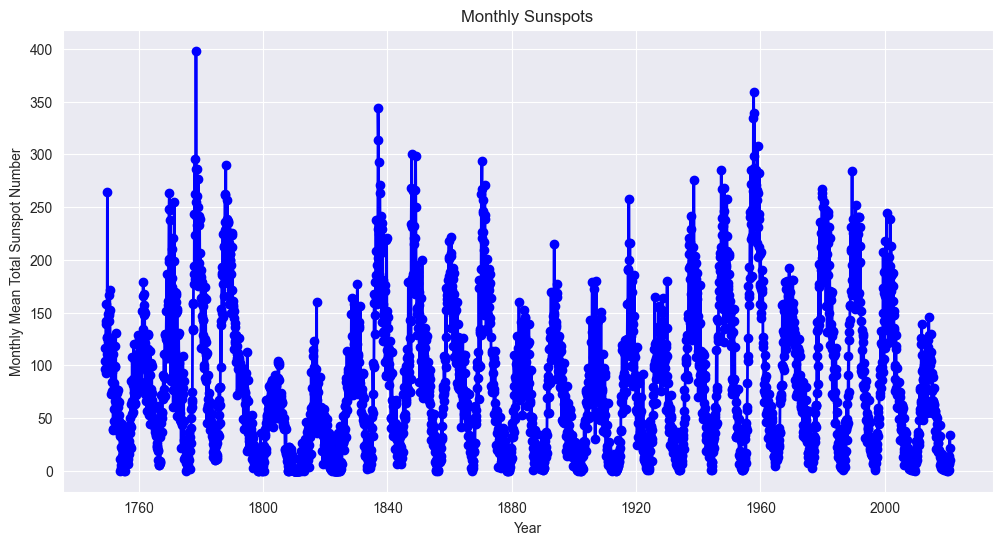

In [95]:
plt.figure(figsize=(12,6))
plt.plot(sunspots.index, sunspots['Monthly Mean Total Sunspot Number'], color='blue', marker='o', linestyle='-', linewidth=2, markersize=6)
plt.title('Monthly Sunspots')
plt.xlabel('Year')
plt.ylabel('Monthly Mean Total Sunspot Number')
plt.show()

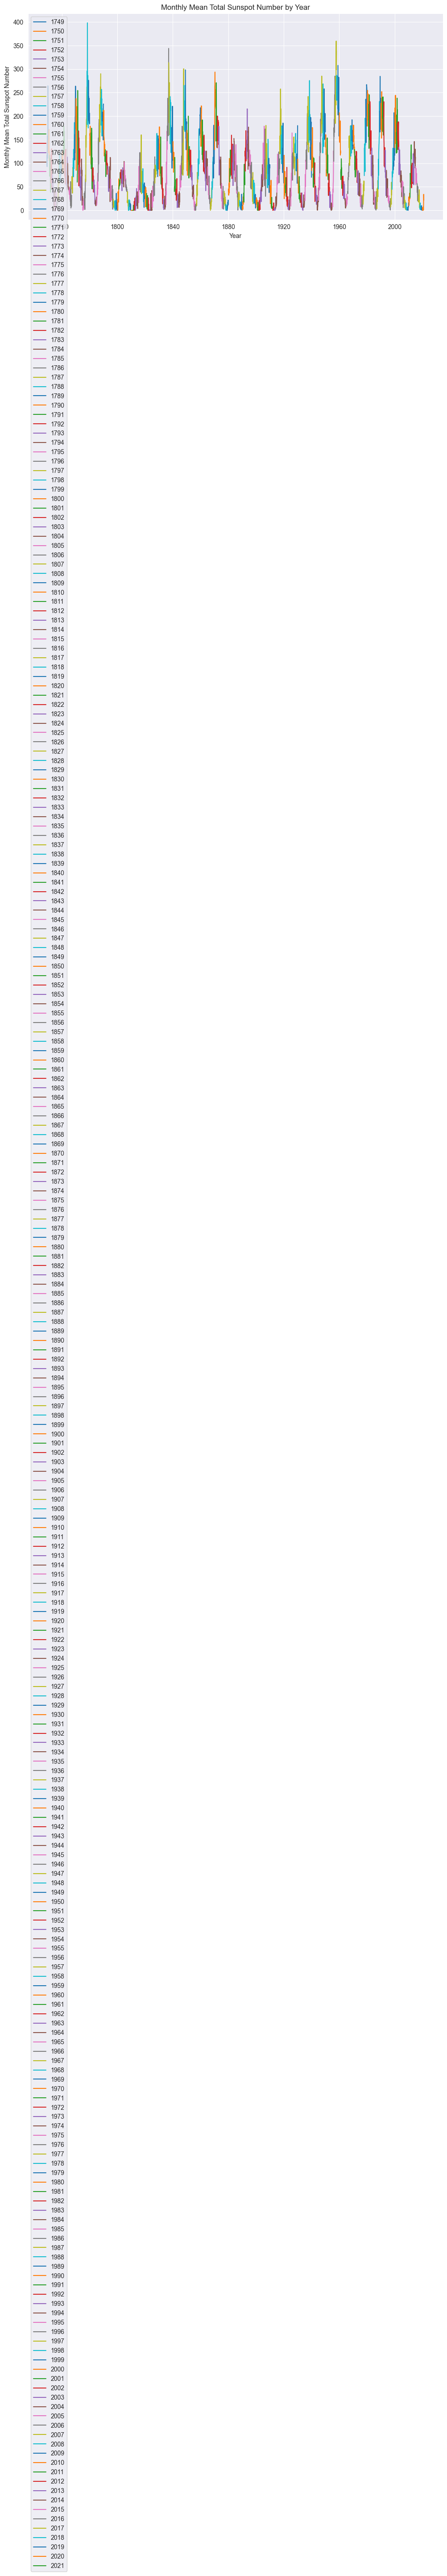

In [96]:
years = sunspots.index.year.unique()

plt.figure(figsize=(12,6))
for year in years:
    year_data = sunspots[sunspots.index.year == year]
    plt.plot(year_data['Monthly Mean Total Sunspot Number'], label=year)
plt.title('Monthly Mean Total Sunspot Number by Year')
plt.xlabel('Year')
plt.ylabel('Monthly Mean Total Sunspot Number')
plt.legend()
plt.grid(True)
plt.show()

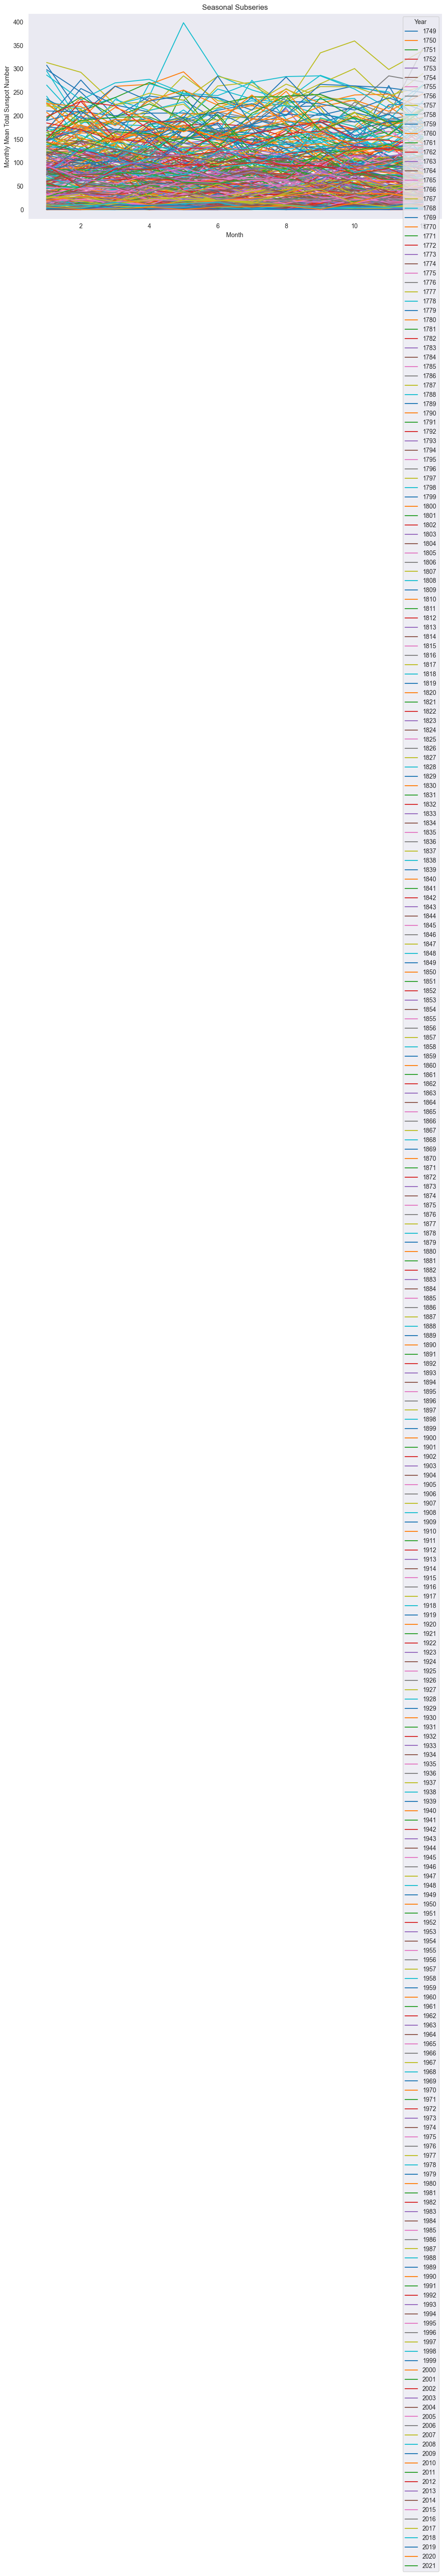

In [97]:
sunspots['Year'] = sunspots.index.year
sunspots['month'] = sunspots.index.month

table = pd.pivot_table(sunspots, values='Monthly Mean Total Sunspot Number', index=['month'], columns='Year', aggfunc='sum')
fig, ax = plt.subplots(figsize=(12, 6))
table.plot(ax=ax, kind='line', legend=True)
ax.set_xlabel('Month')
ax.set_ylabel('Monthly Mean Total Sunspot Number')
ax.set_title('Seasonal Subseries')
plt.grid()
plt.show()

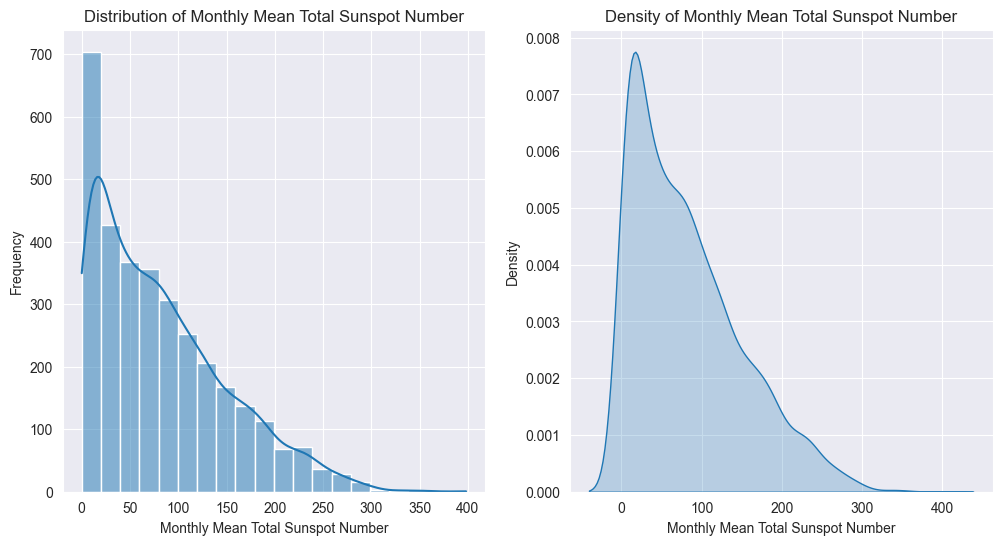

In [98]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(sunspots['Monthly Mean Total Sunspot Number'], bins=20, kde=True)
plt.title('Distribution of Monthly Mean Total Sunspot Number')
plt.xlabel('Monthly Mean Total Sunspot Number')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.kdeplot(sunspots['Monthly Mean Total Sunspot Number'], fill=True)
plt.title('Density of Monthly Mean Total Sunspot Number')
plt.xlabel('Monthly Mean Total Sunspot Number')
plt.show()

**Exercise 2**

Use the unemployment in USA dataset from kaggel

# Idk yet

In [99]:
# Agregamos las siguientes librerias
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose

In [100]:
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10,5)

In [106]:
def plot_series(s, title):
    s.plot()
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.grid(True)
    plt.show()

def adf_test(x):
    res = adfuller(x, autolag='AIC')
    key = ['test_stat', 'pvalue', 'lags', 'nobs', 'critical_values', 'icbest']
    return dict(zip(key, [res[0], res[1], res[2], res[3], res[4], res[5]]))

def kpss_test(x, regression='c', nlag='auto'):
    stat, pvalue, lags, crit = kpss(x, regression=regression, nlags=nlag)
    return {'test_stat': stat, 'pvalue': pvalue, 'lags': lags, 'critical_values': crit, 'regression': regression}

def print_test(x, name='series'):
    print(f'Test {name}')
    a = adf_test(x)
    print(f'ADF Statistic: {a['test_stat']:.3f} p={a['pvalue']}')
    try:
        k = kpss_test(x)
        print(f'KPSS: stat={k['test_stat']:.3f} p={k['pvalue']}')
    except:
        print('KPSS test failes')

def rolling_mean_var(s, window=24, title='Rolling Mean & Var'):
    rolling_mean = s.rolling(window).mean()
    rolling_var = s.rolling(window).var()
    fig, ax = plt.subplots(2, 1, figsize=(10, 6))
    ax[0].plot(s, label='Original')
    ax[0].plot(rolling_mean, label='Rolling Mean')
    ax[0].legend()
    ax[0].set_title(title + '- mean')
    ax[1].plot(rolling_var, label='Rolling Var')
    ax[1].legend()
    ax[1].set_title(title + '- var')
    plt.show()

In [107]:
n = 240 #meses
t = np.arange(n)

#stationary: white noise
white_noise = pd.Series(np.random.normal(0,1,n))

#no estacionaria
trend = .02 * t
trended = pd.Series(trend +np.random.normal(0, 1, n))

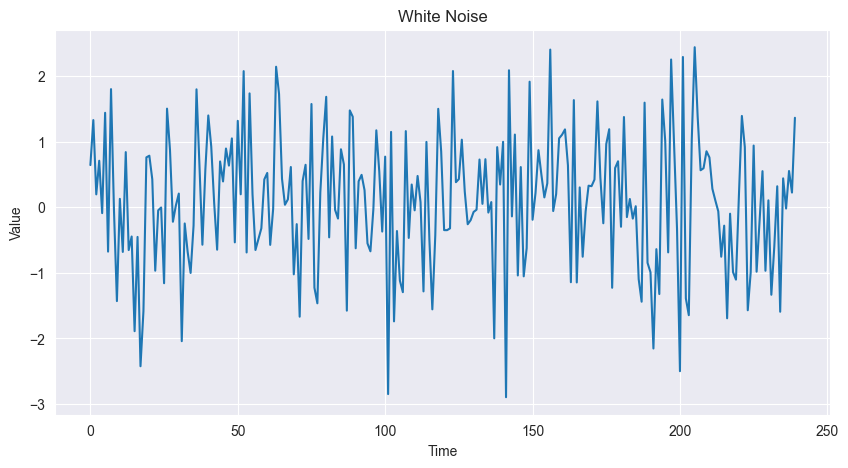

Test White Noise
ADF Statistic: -16.079 p=5.399382048122782e-29
KPSS: stat=0.070 p=0.1


/var/folders/s9/nmcxfjds7tl85gtpmnq8yhv40000gn/T/ipykernel_30772/827597748.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pvalue, lags, crit = kpss(x, regression=regression, nlags=nlag)


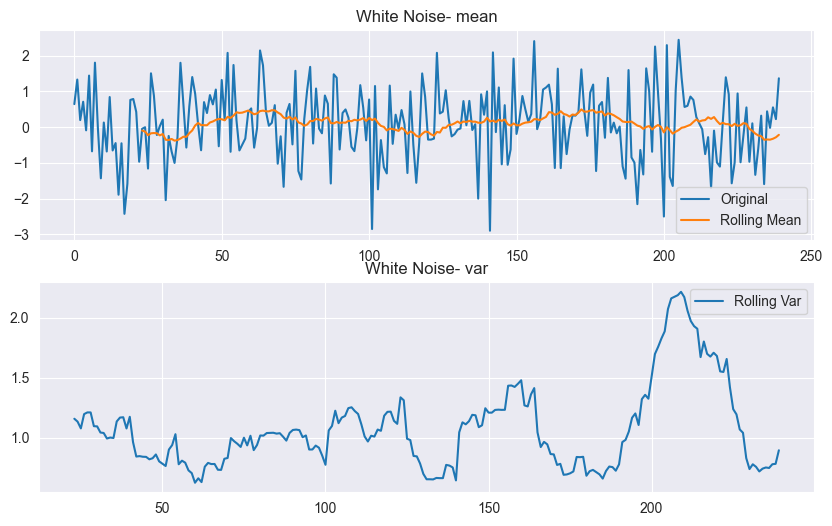

In [108]:
plot_series(white_noise, 'White Noise')
print_test(white_noise, 'White Noise')
rolling_mean_var(white_noise, title='White Noise')

## 20 de octubre

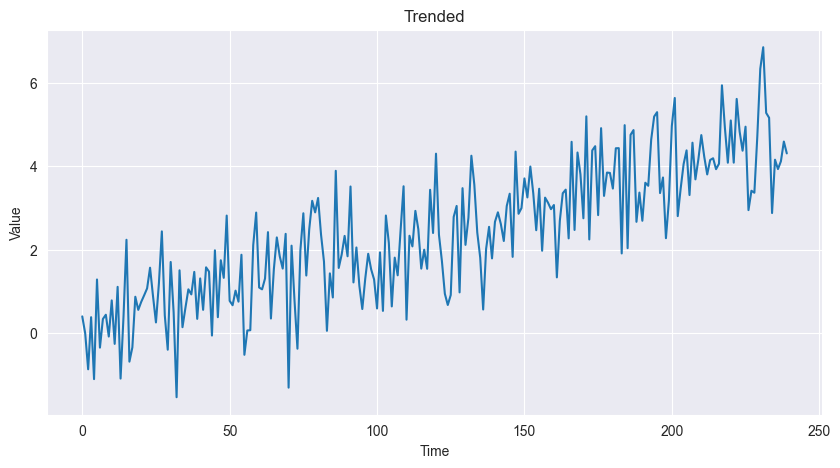

Test Trended
ADF Statistic: -0.743 p=0.8353765746444723
KPSS: stat=2.394 p=0.01


/var/folders/s9/nmcxfjds7tl85gtpmnq8yhv40000gn/T/ipykernel_30772/827597748.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pvalue, lags, crit = kpss(x, regression=regression, nlags=nlag)


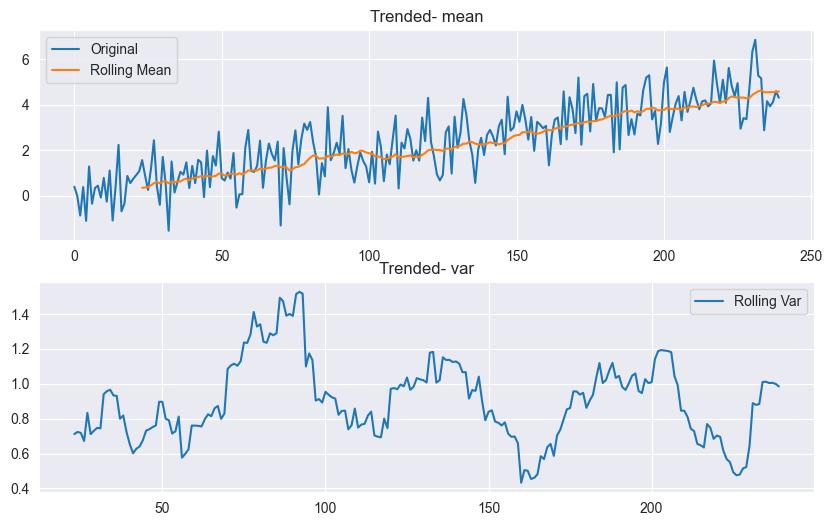

In [111]:
plot_series(trended, 'Trended')
print_test(trended, 'Trended')
rolling_mean_var(trended, window=24, title='Trended')

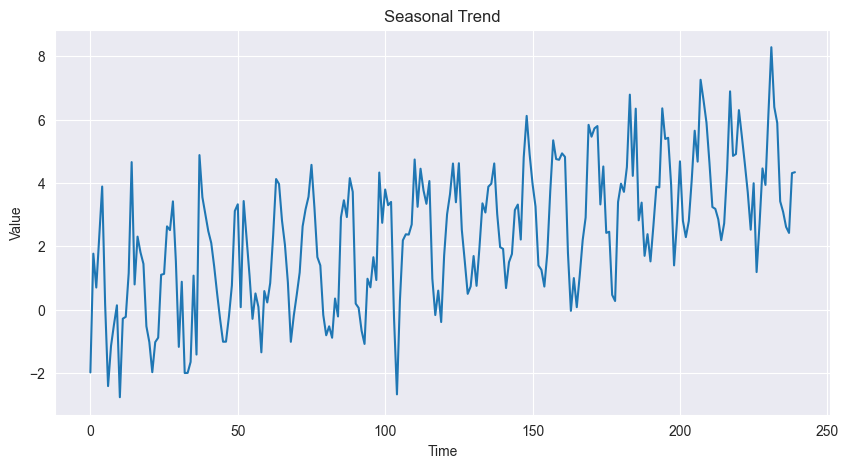

Test Seasonal Trend
ADF Statistic: -0.586 p=0.8741661135740115
KPSS: stat=2.349 p=0.01


/var/folders/s9/nmcxfjds7tl85gtpmnq8yhv40000gn/T/ipykernel_30772/827597748.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pvalue, lags, crit = kpss(x, regression=regression, nlags=nlag)


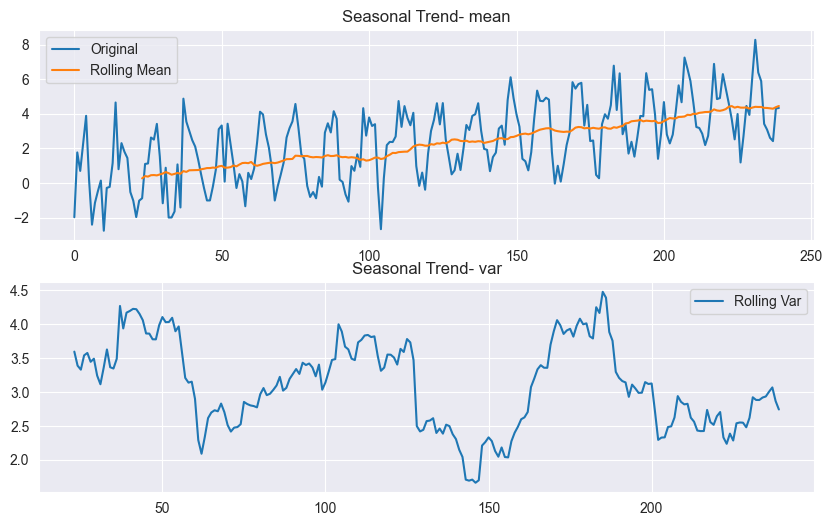

In [112]:
#seasonal  + trend
seasonal = 2 * np.sin(2*np.pi*t/12)
trend = 0.02 * t
season_trend = pd.Series(trend + seasonal + np.random.normal(0,1,n))
plot_series(season_trend, 'Seasonal Trend')
print_test(season_trend, 'Seasonal Trend')
rolling_mean_var(season_trend, window=24, title='Seasonal Trend')

In [113]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.head(10)

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


In [114]:
df.rename(columns={'Passengers':'y'}, inplace=True)
df.head()

,y
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


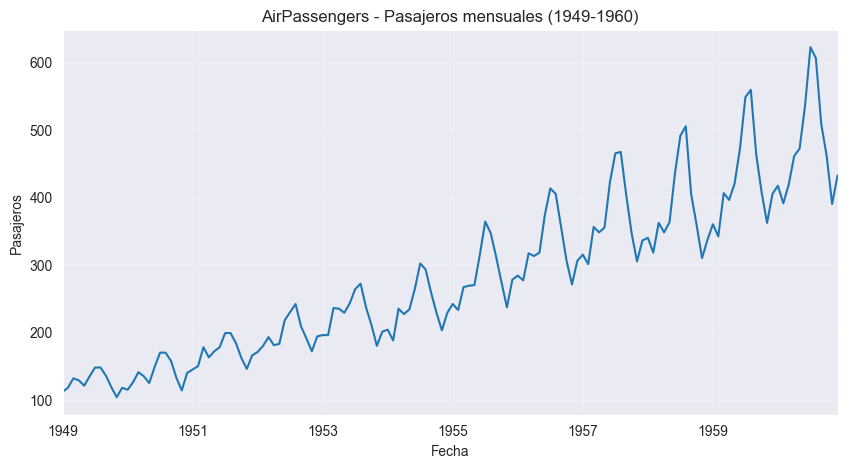

In [115]:
ax = df['y'].plot()
ax.set_title('AirPassengers - Pasajeros mensuales (1949-1960)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Pasajeros')
ax.grid(True, alpha=0.3)
plt.show()

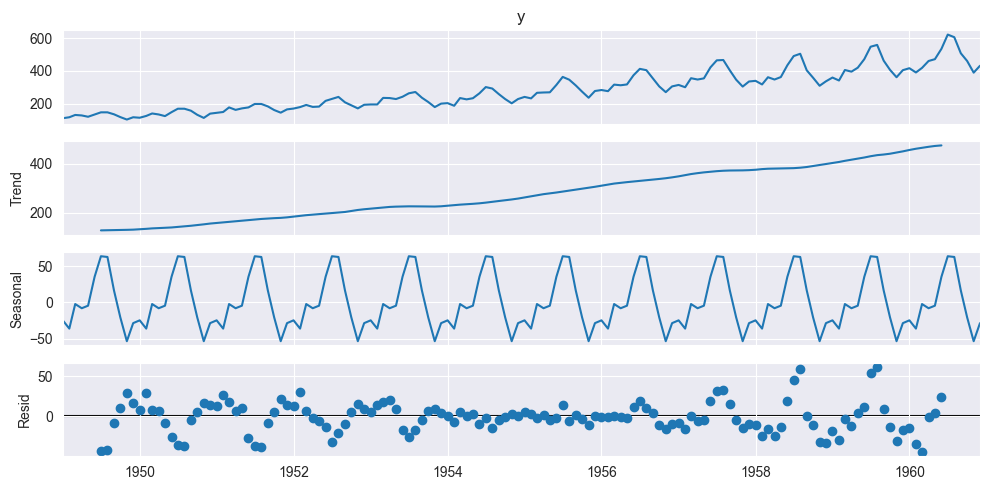

In [116]:
decomp = seasonal_decompose(df['y'], model='additive', period=12)
decomp.plot()
plt.show()

In [117]:
from statsmodels.tsa.ar_model import AutoReg

model = AutoReg(df['y'], lags =1)
model_fit = model.fit()

print(model_fit.summary())

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  144
Model:                     AutoReg(1)   Log Likelihood                -704.106
Method:               Conditional MLE   S.D. of innovations             33.277
Date:                Fri, 14 Nov 2025   AIC                           1414.212
Time:                        15:40:44   BIC                           1423.100
Sample:                    02-01-1949   HQIC                          1417.823
                         - 12-01-1960                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.7055      7.084      1.935      0.053      -0.178      27.589
y.L1           0.9589      0.023     41.106      0.000       0.913       1.005
                                    Roots           

/Users/wil/Documents/TEC/AdvancedAI_Python-Stats/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


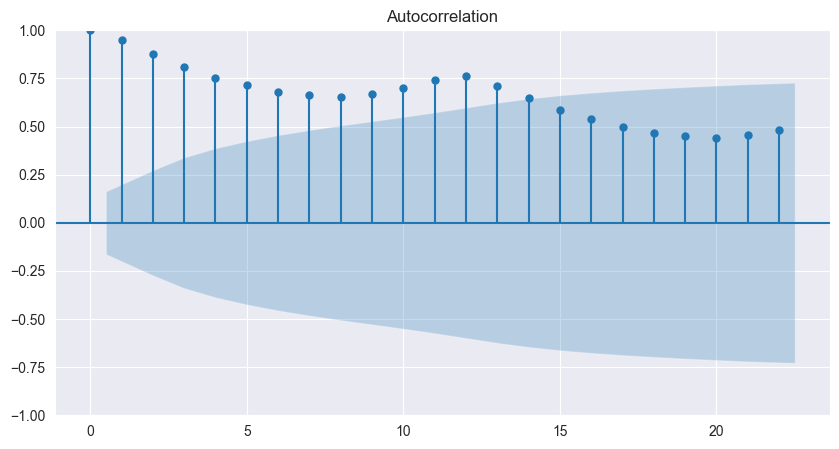

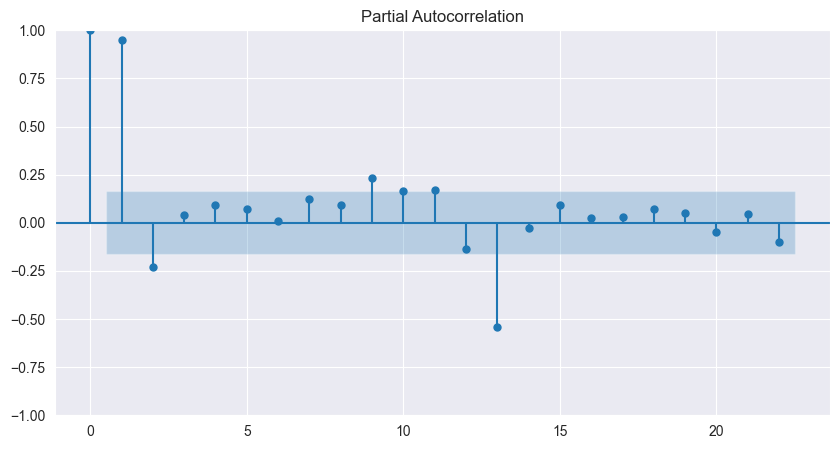

In [122]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['y'])
plt.show()
plot_pacf(df['y'])
plt.show()

# ARIMA

In [121]:
#Fit an ARIMA(1,1,1)
model = ARIMA(df['y'], order=(1,1,1))
model_fit = model.fit()

# Print the model summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  144
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -694.341
Date:                Fri, 14 Nov 2025   AIC                           1394.683
Time:                        15:41:40   BIC                           1403.571
Sample:                    01-01-1949   HQIC                          1398.294
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4742      0.123     -3.847      0.000      -0.716      -0.233
ma.L1          0.8635      0.078     11.051      0.000       0.710       1.017
sigma2       961.9270    107.433      8.954      0.0

/Users/wil/Documents/TEC/AdvancedAI_Python-Stats/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/wil/Documents/TEC/AdvancedAI_Python-Stats/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/wil/Documents/TEC/AdvancedAI_Python-Stats/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


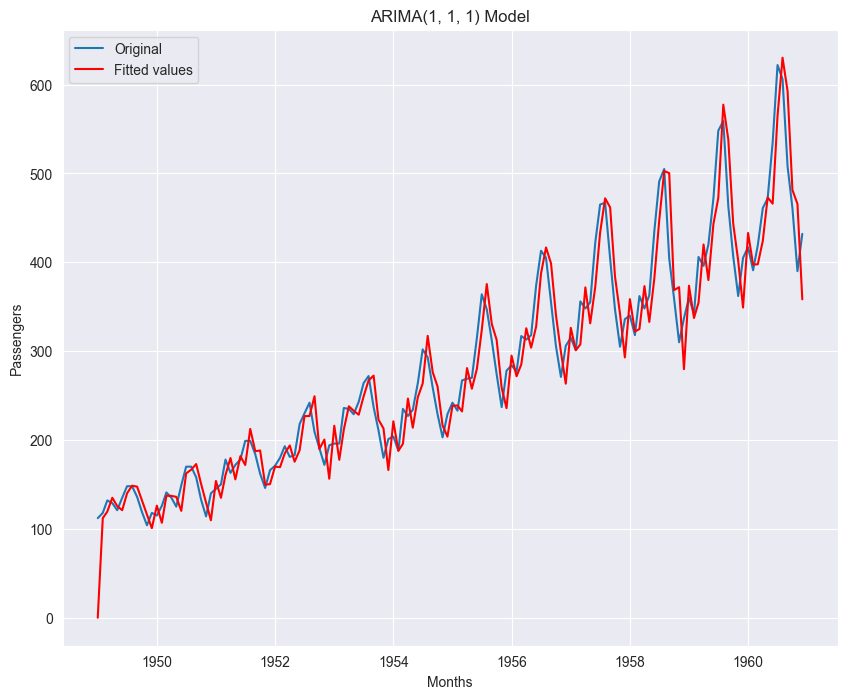

In [124]:
plt.figure(figsize=(10, 8))
plt.plot(df['y'], label = 'Original')
plt.plot(model_fit.fittedvalues, color = 'red', label = 'Fitted values')
plt.title('ARIMA(1, 1, 1) Model')
plt.xlabel('Months')
plt.ylabel('Passengers')
plt.legend()
plt.show()